<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Global_Gender_Equality_Rankings_2023_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Gender Equality Rankings 2023 Dataset

# About this dataset

This comprehensive dataset, titled 'Global Gender Equality Rankings 2023', offers a critical snapshot of gender inequality across 193 unique entries, predominantly individual countries, for the specific year 2023. It comprises six columns: 'Scraped_Date', 'Data_Year', 'Country', 'ISO3', 'Year', and the pivotal 'Gender Inequality Index (GII)'. A key characteristic is the static nature of 'Scraped_Date', 'Data_Year', and 'Year', which consistently show '2025-11-23' and '2023' respectively. This constancy signifies that the dataset captures a single point in time, precluding any direct longitudinal analysis. Additionally, the 'ISO3' column has 20 missing values, primarily for aggregated regional entities rather than specific nations, an important detail for interpretation.

The central and most insightful metric is the 'Gender Inequality Index (GII)'. Its values span a considerable range, from a low of 0.003 to a high of 0.838, with an overall average hovering around 0.332. This broad distribution immediately highlights significant disparities in gender equality levels worldwide. For instance, Afghanistan exhibits a notably high GII of 0.661, indicative of substantial gender inequality, whereas Australia demonstrates a remarkably low GII of 0.056, suggesting a far greater degree of gender equality. The exploratory data analysis confirms the GII as the sole dynamic and truly informative numerical metric. Categorical columns, particularly 'Country', serve as direct identifiers linking specific nations to their GII scores, making the GII the focal point for understanding global gender equality standings in 2023.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hammadfarooq470/global-gender-equality-rankings-2023

# Unziping the downloaded file
!unzip global-gender-equality-rankings-2023.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hammadfarooq470/global-gender-equality-rankings-2023
License(s): MIT
  0% 0.00/2.64k [00:00<?, ?B/s]
100% 2.64k/2.64k [00:00<00:00, 11.4MB/s]
Archive:  global-gender-equality-rankings-2023.zip
  inflating: combined_global_gender_data_20251123.csv  


In [3]:
df = pd.read_csv('combined_global_gender_data_20251123.csv')
df.head(11)

,Scraped_Date,Data_Year,Country,ISO3,Year,Gender Inequality Index (GII) (Gender Inequality Index)
0,2025-11-23,2023,Afghanistan,AFG,2023,0.661000
1,2025-11-23,2023,Africa,NaN,2023,0.530450
2,2025-11-23,2023,Albania,ALB,2023,0.107000
3,2025-11-23,2023,Algeria,DZA,2023,0.443000
4,2025-11-23,2023,Angola,AGO,2023,0.515000
5,2025-11-23,2023,Antigua and Barbuda,ATG,2023,0.240000
6,2025-11-23,2023,Arab States (UNDP),NaN,2023,0.539000
7,2025-11-23,2023,Argentina,ARG,2023,0.264000
8,2025-11-23,2023,Armenia,ARM,2023,0.180000
9,2025-11-23,2023,Asia,NaN,2023,0.310431


In [4]:
df.tail(11)

,Scraped_Date,Data_Year,Country,ISO3,Year,Gender Inequality Index (GII) (Gender Inequality Index)
182,2025-11-23,2023,Upper-middle-income countries,NaN,2023,0.246307
183,2025-11-23,2023,Uruguay,URY,2023,0.218000
184,2025-11-23,2023,Uzbekistan,UZB,2023,0.291000
185,2025-11-23,2023,Vanuatu,VUT,2023,0.556000
186,2025-11-23,2023,Venezuela,VEN,2023,0.512000
187,2025-11-23,2023,Very high human development (UNDP),NaN,2023,0.125000
188,2025-11-23,2023,Vietnam,VNM,2023,0.299000
189,2025-11-23,2023,World,OWID_WRL,2023,0.455000
190,2025-11-23,2023,Yemen,YEM,2023,0.838000
191,2025-11-23,2023,Zambia,ZMB,2023,0.524000


In [5]:
df.shape

(193, 6)

In [6]:
df.columns

Index(['Scraped_Date', 'Data_Year', 'Country', 'ISO3', 'Year',
       'Gender Inequality Index (GII) (Gender Inequality Index)'],
      dtype='object')

In [7]:
df.dtypes

,0
Scraped_Date,object
Data_Year,int64
Country,object
ISO3,object
Year,int64
Gender Inequality Index (GII) (Gender Inequality Index),float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Scraped_Date                                             193 non-null    object 
 1   Data_Year                                                193 non-null    int64  
 2   Country                                                  193 non-null    object 
 3   ISO3                                                     173 non-null    object 
 4   Year                                                     193 non-null    int64  
 5   Gender Inequality Index (GII) (Gender Inequality Index)  193 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 9.2+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Scraped_Date,193,1,2025-11-23,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Year,193.0,NaN,NaN,NaN,2023.0,0.0,2023.0,2023.0,2023.0,2023.0,2023.0
Country,193,193,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISO3,173,173,AFG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,193.0,NaN,NaN,NaN,2023.0,0.0,2023.0,2023.0,2023.0,2023.0,2023.0
Gender Inequality Index (GII) (Gender Inequality Index),193.0,NaN,NaN,NaN,0.331953,0.194076,0.003,0.169,0.352,0.492,0.838


In [10]:
df.isnull().sum()

,0
Scraped_Date,0
Data_Year,0
Country,0
ISO3,20
Year,0
Gender Inequality Index (GII) (Gender Inequality Index),0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

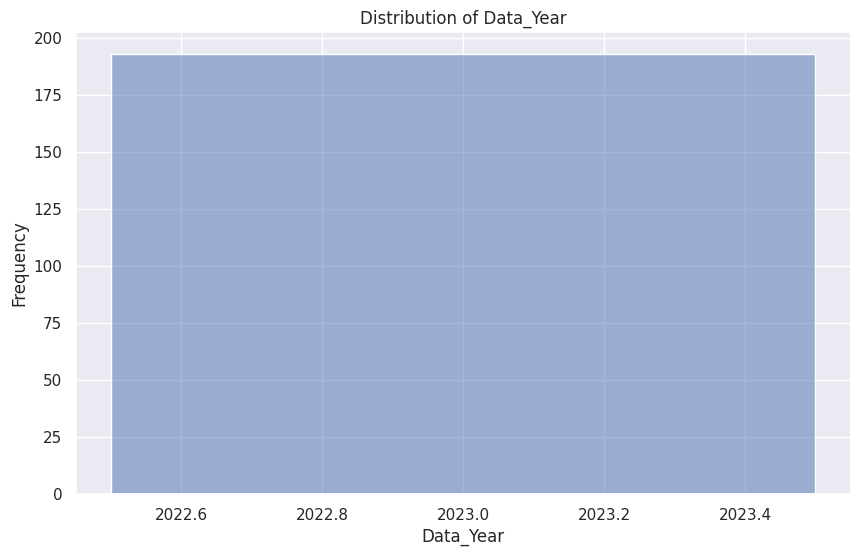

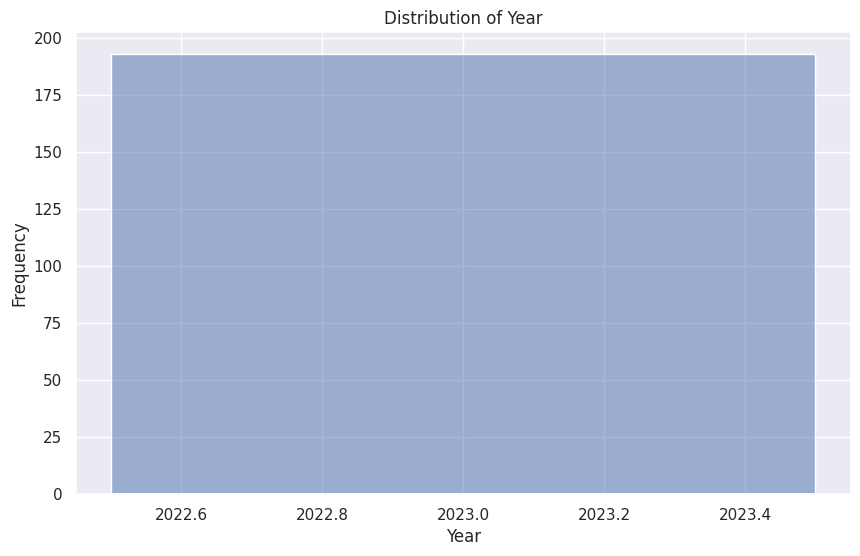

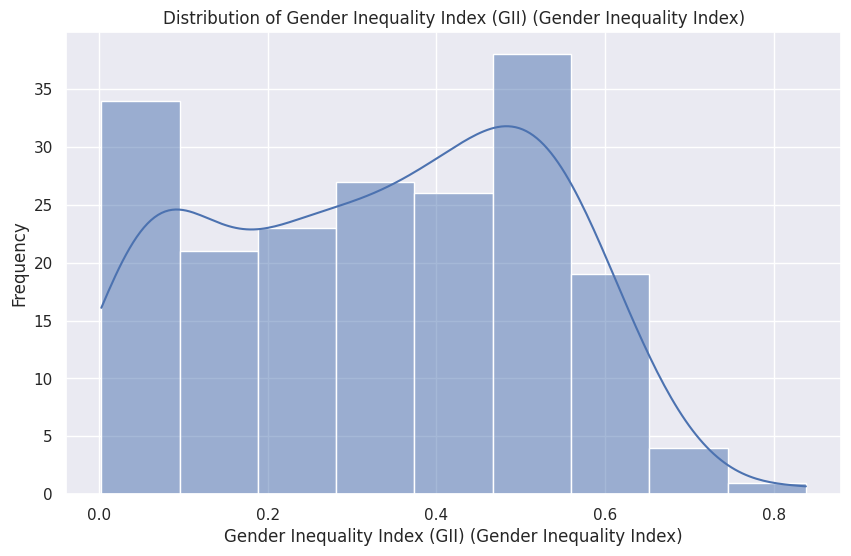

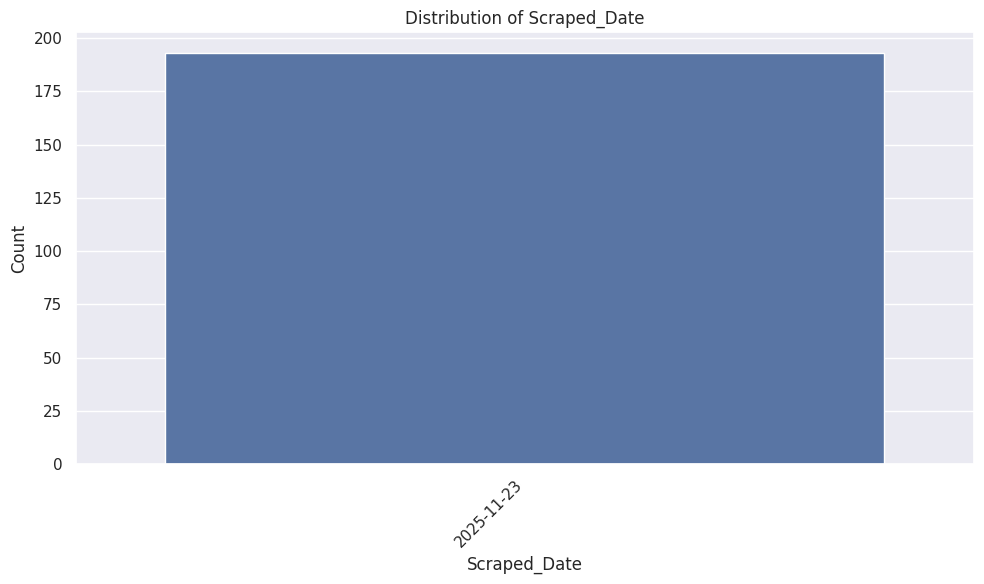

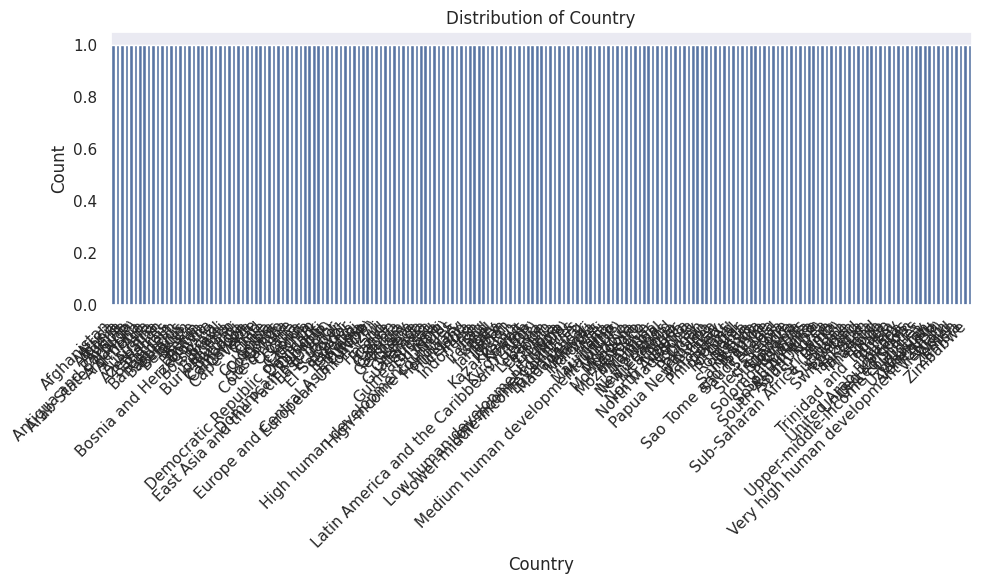

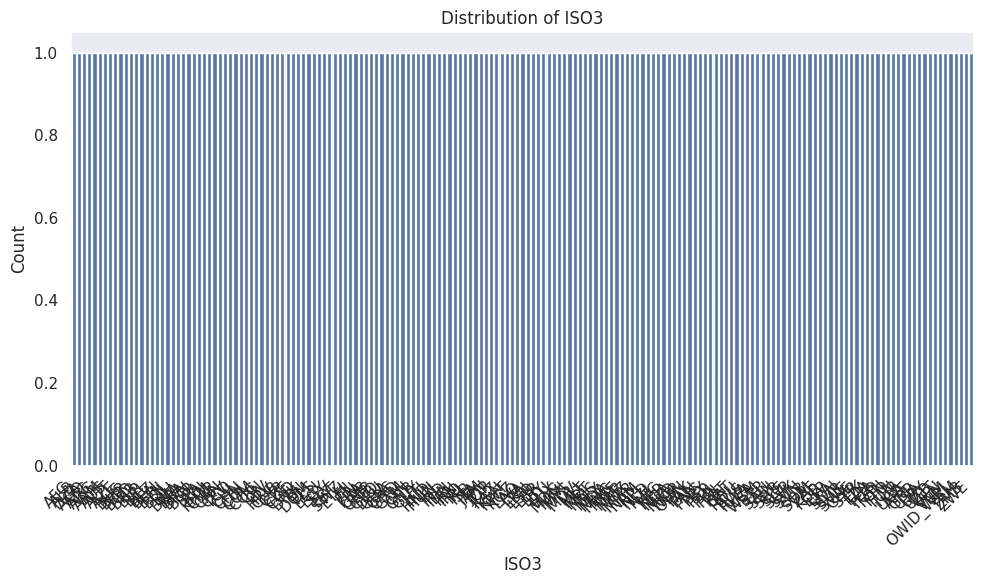

Value counts for Scraped_Date:
Scraped_Date
2025-11-23    193
Name: count, dtype: int64

Value counts for Country:
Country
Afghanistan    1
Africa         1
Albania        1
Algeria        1
Angola         1
              ..
Vietnam        1
World          1
Yemen          1
Zambia         1
Zimbabwe       1
Name: count, Length: 193, dtype: int64

Value counts for ISO3:
ISO3
AFG         1
ALB         1
DZA         1
AGO         1
ATG         1
           ..
VNM         1
OWID_WRL    1
YEM         1
ZMB         1
ZWE         1
Name: count, Length: 173, dtype: int64



In [12]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

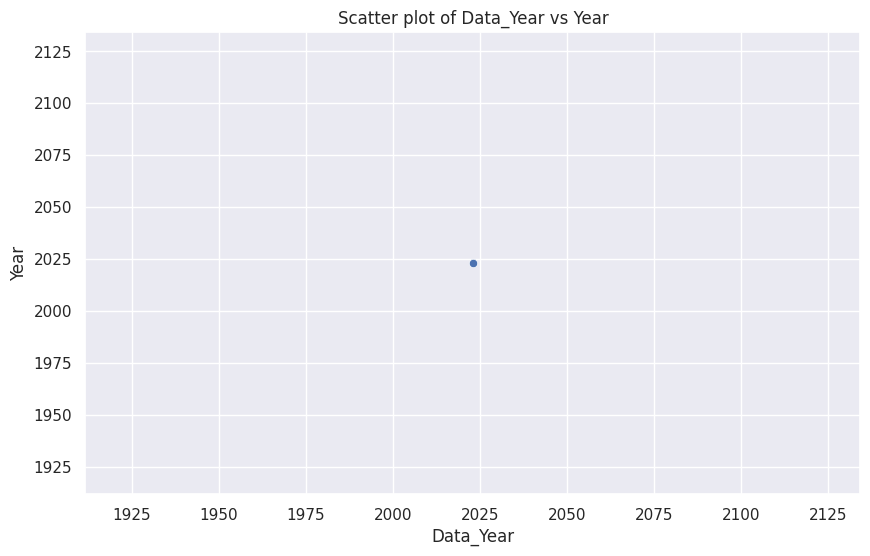

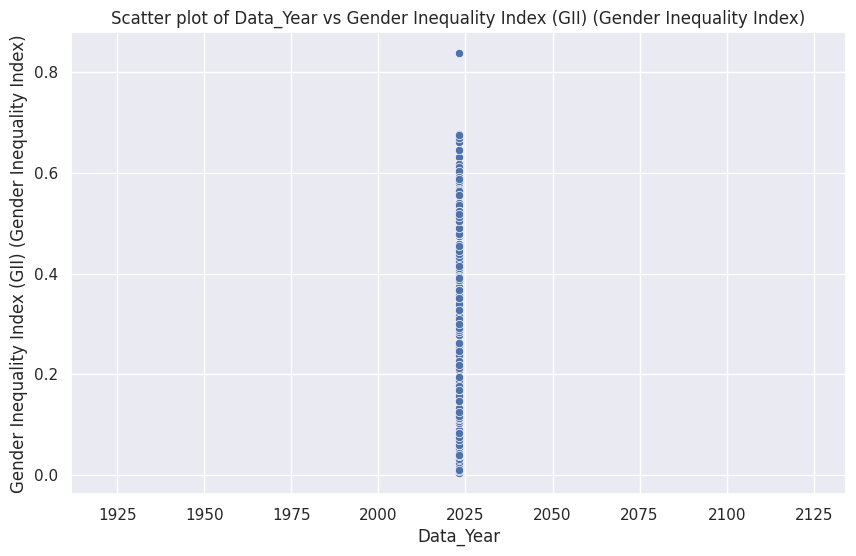

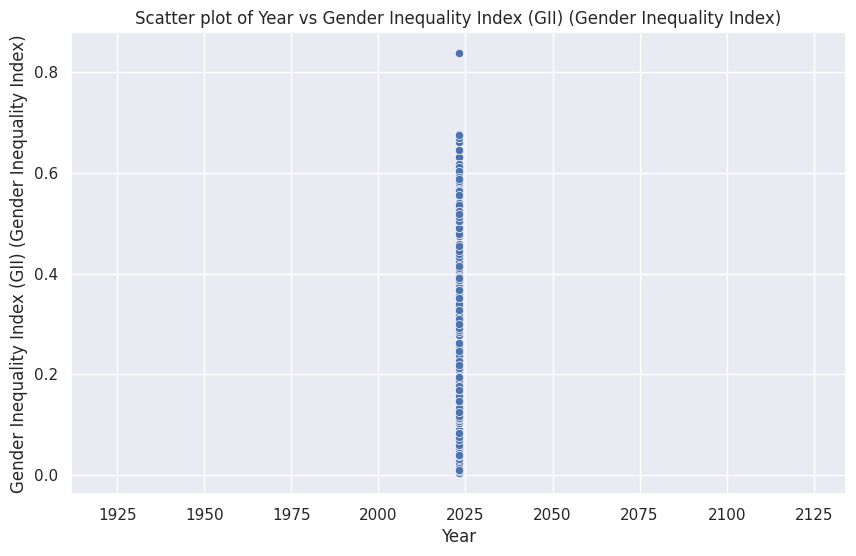

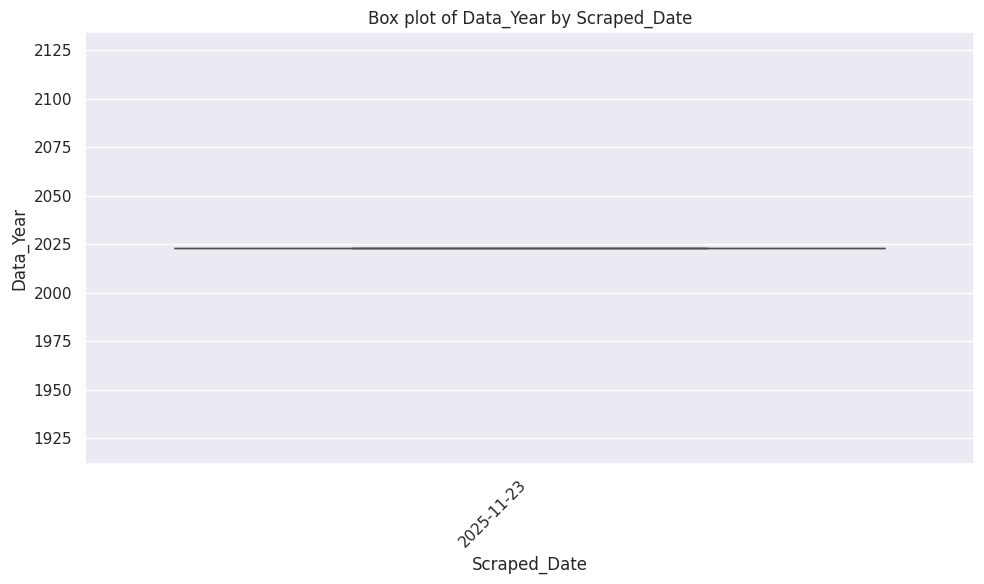

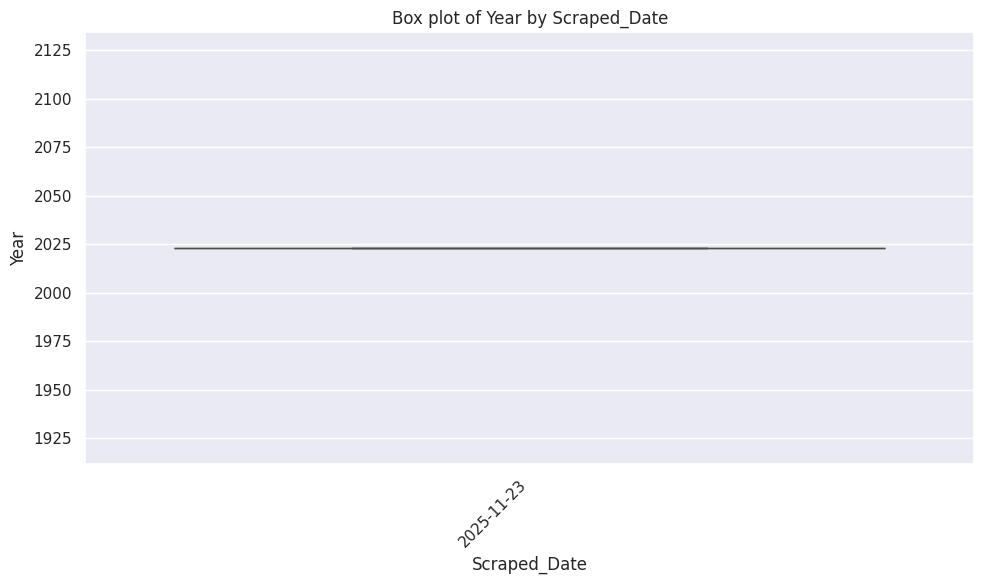

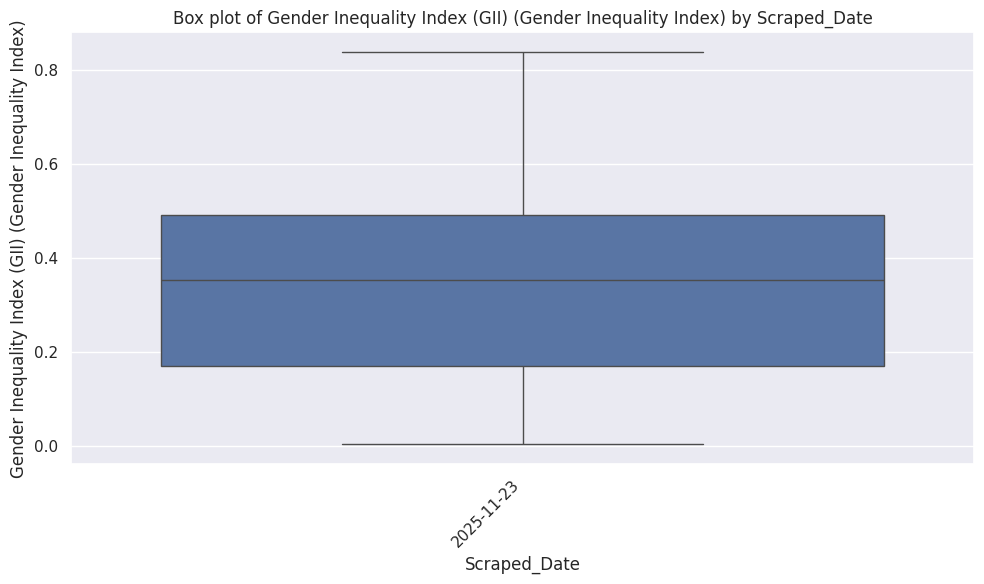

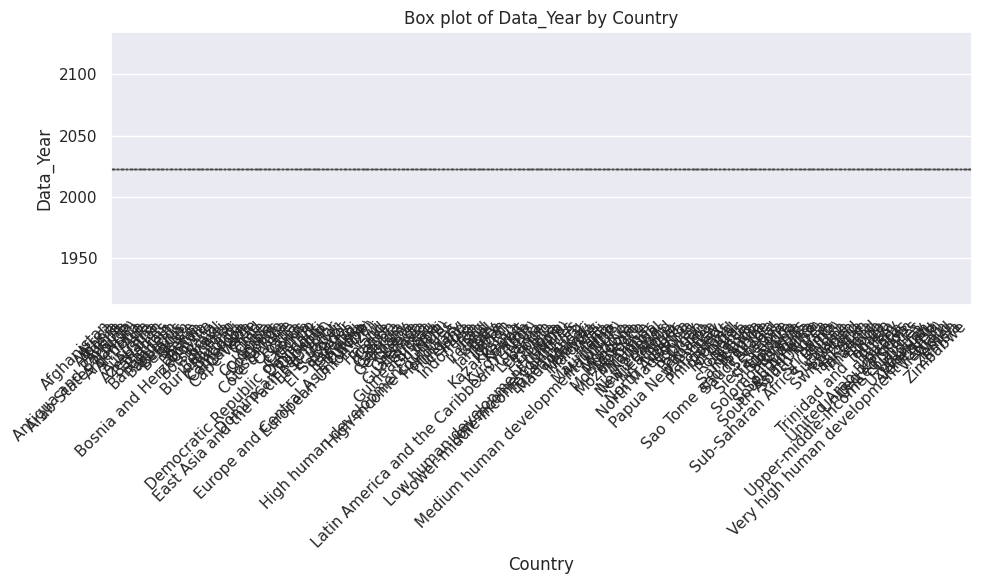

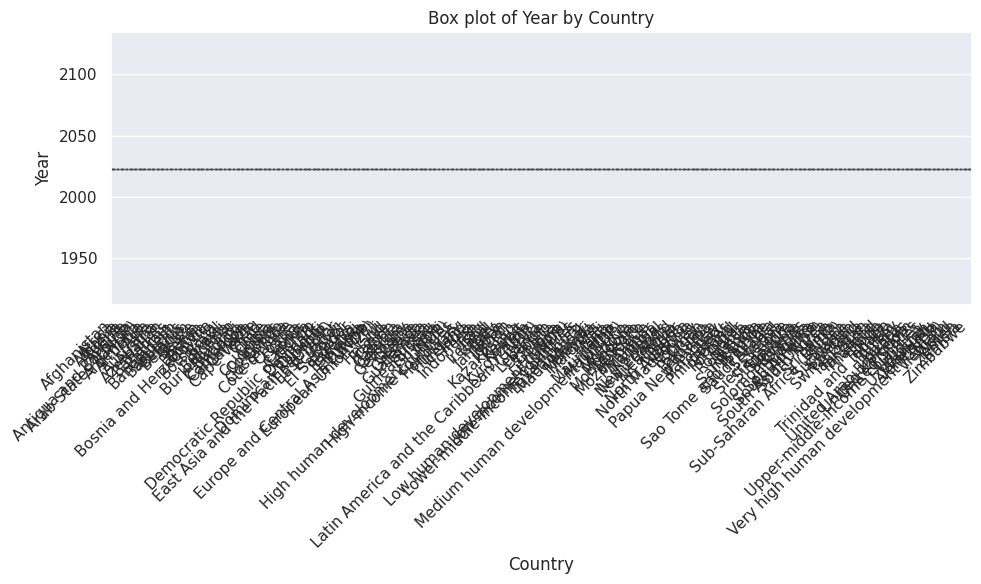

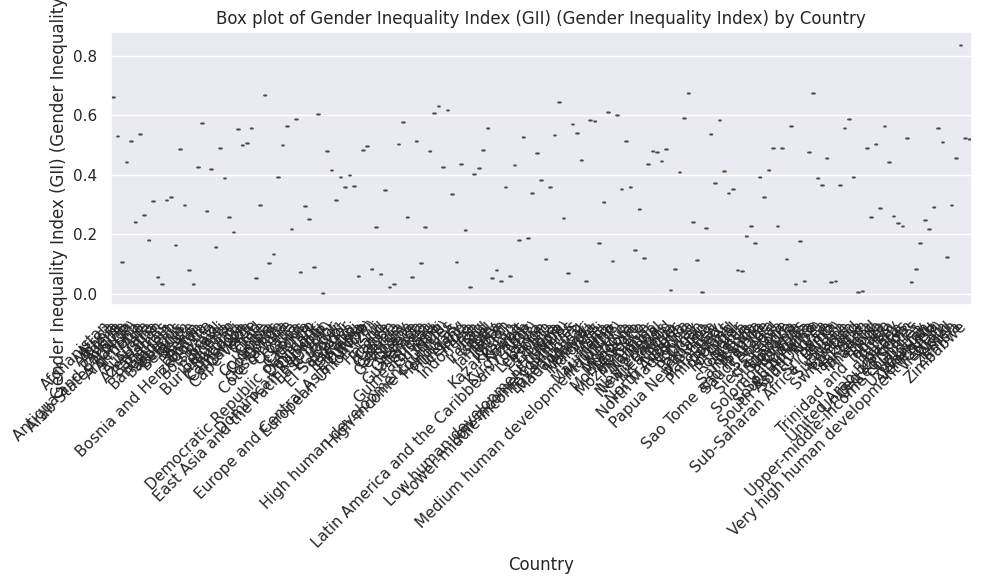

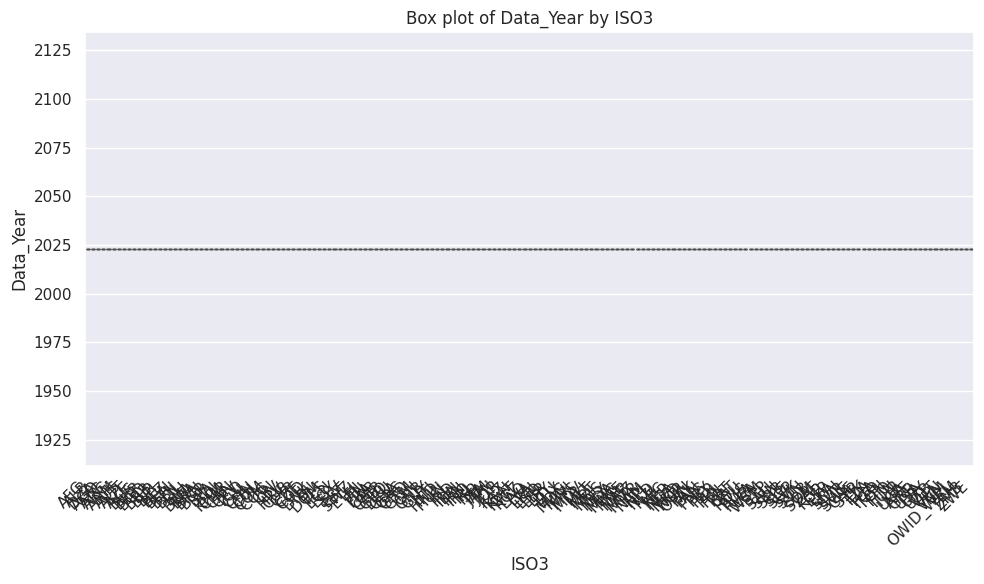

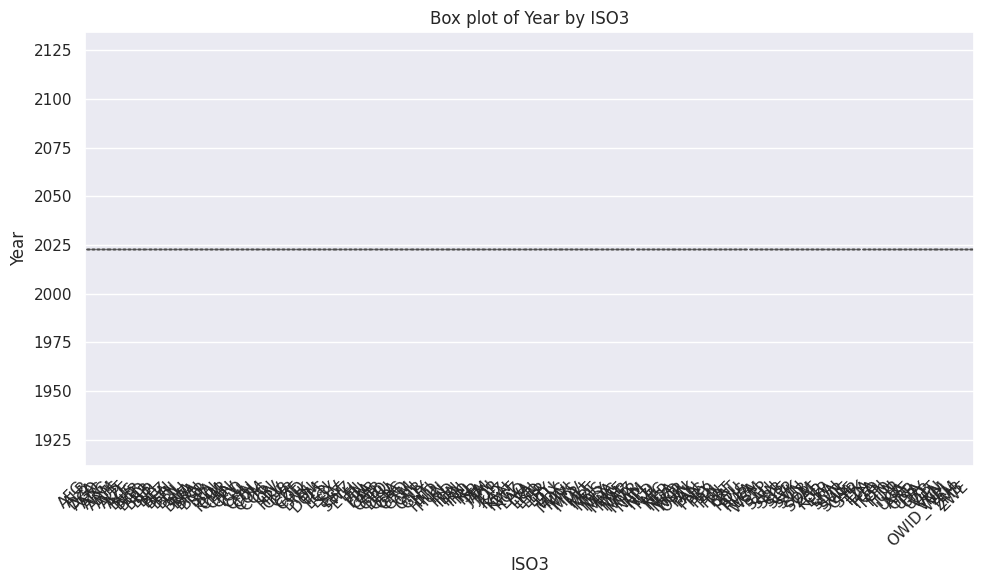

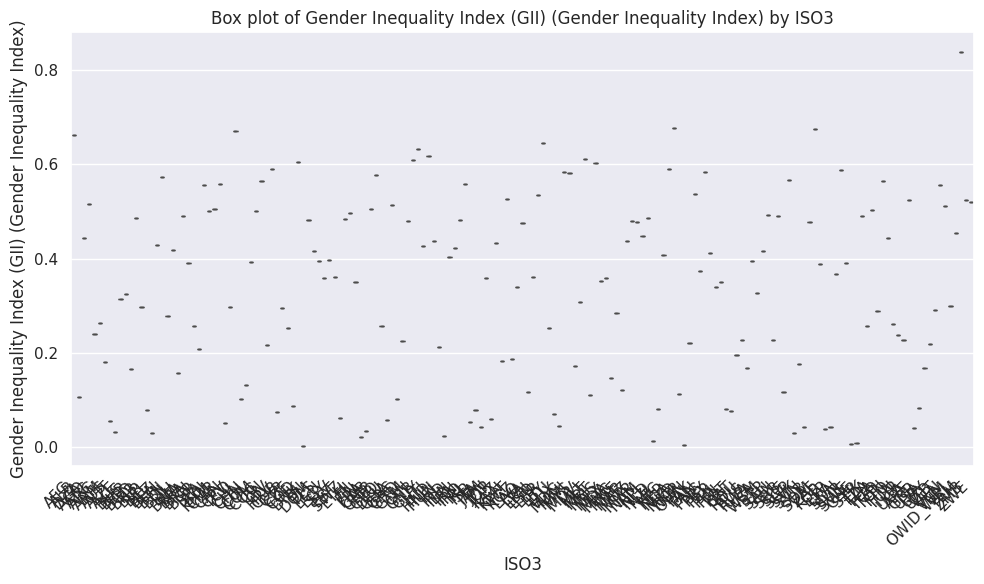

In [13]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Pair-Plot

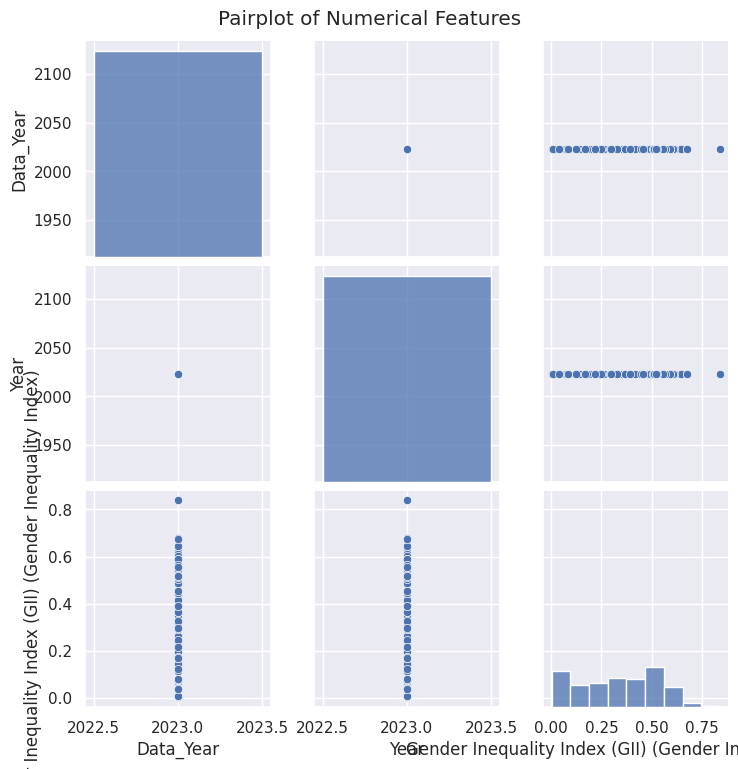

In [14]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

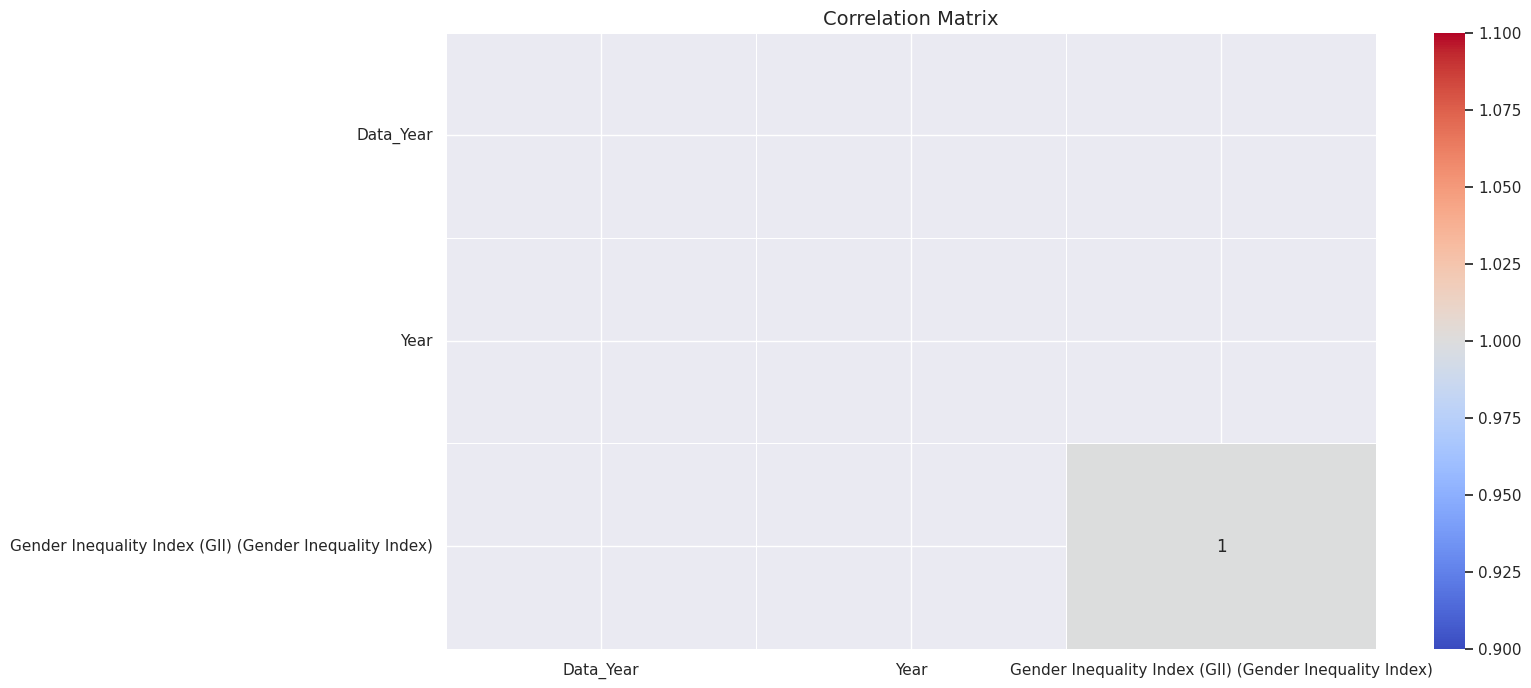

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You